# 1. Kutubxonalarni chaqirish va ish muhitini tayyorlash

Ma'lumotlarni tahlil qilish va vizualizatsiya qilish uchun kerakli kutubxonalarni yuklab olamiz.

In [217]:
import pandas as pd
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Ma'lumotlarni yuklash va dastlabki tozalash

CSV fayldan ma'lumotlarni yuklaymiz va ustun nomlaridagi ortiqcha bo'shliqlarni olib tashlaymiz.

In [218]:
# # Ma'lumotlarni yuklash

from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

df = X.join(y)

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [220]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no


# 3. Sanalarni to'g'irlash va 20XX formatga keltirish

Sanalarni datetime formatiga o'tkazamiz va eski yillarni 20XX shakliga keltiramiz.

# B.P2 — Standart markaziy moyillik va tarqoqlik o'lchovlari asosidagi statistik tahlil

Ushbu bosqichda Sales, Discount va Profit ustunlari uchun asosiy statistik ko‘rsatkichlar hisoblanadi. O‘rtacha qiymat (Mean), mediana (Median), moda (Mode), dispersiya (Variance) va standart og‘ish (Standard Deviation) aniqlanadi. Shuningdek, Profit ustunining taqsimoti tahlil qilinadi: gistoramma chiziladi va ma'lumotlarning normal taqsimotga mosligi tekshiriladi.

In [221]:
# Переименование колонки (если есть)
df.rename(columns={'day_of_week': 'day'}, inplace=True)

# Установим порядок месяцев
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
df['day'] = df['day'].astype(int)

# ---------- Присваиваем year ----------
year = 2008
years = []
prev_month = None
prev_day = None

for _, row in df.iterrows():
    curr_month = row['month']
    curr_day = row['day']

    if prev_month is not None:
        if month_order.index(curr_month) < month_order.index(prev_month):
            year += 1
        elif curr_month == prev_month and curr_day < prev_day:
            year += 1

    years.append(year)
    prev_month = curr_month
    prev_day = curr_day

df['year'] = years

# ---------- Создаем колонку 'date' ----------
df['date'] = pd.to_datetime(
    df['day'].astype(str) + '-' + df['month'].astype(str) + '-' + df['year'].astype(str),
    format='%d-%b-%Y'
)

# ---------- Добавляем 'weekday' ----------
df['weekday'] = df['date'].dt.strftime('%a').str.lower()
df['weekday'] = df['weekday'].map({
    'mon': 'mon', 'tue': 'tue', 'wed': 'wed',
    'thu': 'thu', 'fri': 'fri', 'sat': 'sat', 'sun': 'sun'
})

In [222]:
# ---------- Удаляем временные колонки 'day', 'month', 'year' ----------
df.drop(columns=['day', 'month', 'year'], inplace=True)

# Удаление дубликатов
df = df.drop_duplicates().reset_index(drop=True)

# Замена строк 'unknown' (если есть) на NaN — на всякий случай
df.replace('unknown', np.nan, inplace=True)

# Проверка пропущенных значений
print("Пропущенные значения по столбцам:")
print(df.isna().sum())

df = df[df['balance'] <= 30000].reset_index(drop=True)

# Удаление строк с NaN (если нужно)
df = df.dropna().reset_index(drop=True)

column_order = [
    # 🔹 1. Кто это (персональные данные)
    'age', 'marital', 'education', 'job', 'default',

    # 🔹 2. Финансовое состояние
    'balance', 'housing', 'loan',

    # 🔹 3. Когда связались
    'date', 'weekday',

    # 🔹 4. Как связались в текущей кампании
    'contact', 'duration', 'campaign',

    # 🔹 5. Что было до этого (предыдущие кампании)
    'previous', 'pdays', 'poutcome',

    # 🔹 6. Цель
    'y'
]

df = df[[col for col in column_order if col in df.columns]]

Пропущенные значения по столбцам:
age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
date             0
weekday          0
dtype: int64


# Age ustuni bo‘yicha statistik tahlil

Age ustuni uchun o‘rtacha qiymat, mediana, moda, dispersiya va standart og‘ish quyidagicha hisoblanadi.

In [189]:
print(f"Duration uchun o'rtacha qiymat (Mean): {df['duration'].mean():.4f}")
print(f"Duration uchun mediana qiymat (Median): {df['duration'].median():.4f}")
print(f"Duration uchun moda qiymat (Mode): {df['duration'].mode()[0]:.4f}")
print(f"Duration uchun dispersiya qiymati (Variance): {df['duration'].var():.4f}")
print(f"Duration uchun standart og'ish qiymati (Standard Deviation): {df['duration'].std():.4f}")

Duration uchun o'rtacha qiymat (Mean): 261.1949
Duration uchun mediana qiymat (Median): 194.0000
Duration uchun moda qiymat (Mode): 158.0000
Duration uchun dispersiya qiymati (Variance): 55808.9644
Duration uchun standart og'ish qiymati (Standard Deviation): 236.2392


“Duration” ustunidagi ma’lumotlarni tahlil qilish natijasida o‘rtacha qiymat 261.19, median 194.00 va moda 158.00 deb belgilandi. O‘rtacha qiymat medianadan sezilarli darajada yuqori bo‘lgani ushbu ustundagi ma’lumotlarning chapga og‘gan (asymmetric) taqsimotga ega ekanligini bildiradi. Moda va median qiymatlarining yaqinligi esa ko‘pchilik suhbatlar nisbatan qisqa bo‘lganini ko‘rsatadi. Dispersiya 55 808.96, standart og‘ish esa 236.24 bo‘lib, duration qiymatlari atrofida katta tafovut borligini ko‘rsatadi. Bu esa, mijozlar bilan bo‘lgan suhbatlar davomiyligi o‘ta o‘zgaruvchan bo‘lganini, ba’zilar bilan suhbatlar juda qisqa, boshqalar bilan esa ancha uzun davom etganini anglatadi. Bunday tarqoqlik mijozlarning ehtiyojlari va menejerlarning yondashuviga qarab farqlanishi mumkinligini ko‘rsatadi.

# Balance ustuni bo‘yicha statistik tahlil

Balance ustuni uchun o‘rtacha qiymat, mediana, moda, dispersiya va standart og‘ish quyidagicha hisoblanadi:


In [190]:
print(f"Balance ustuni uchun o‘rtacha qiymat (Mean): {df['balance'].mean():.4f}")
print(f"Balance ustuni uchun mediana qiymat (Median): {df['balance'].median():.4f}")
print(f"Balance ustuni uchun moda qiymat (Mode): {df['balance'].mode()[0]:.4f}")
print(f"Balance ustuni uchun dispersiya qiymati (Variance): {df['balance'].var():.4f}")
print(f"Balance ustuni uchun standart og‘ish qiymati (Standard Deviation): {df['balance'].std():.4f}")

Balance ustuni uchun o‘rtacha qiymat (Mean): 1508.9081
Balance ustuni uchun mediana qiymat (Median): 592.0000
Balance ustuni uchun moda qiymat (Mode): 0.0000
Balance ustuni uchun dispersiya qiymati (Variance): 7027635.0927
Balance ustuni uchun standart og‘ish qiymati (Standard Deviation): 2650.9687


“Balance” ustunidagi statistik tahlil natijalariga ko‘ra, o‘rtacha qiymat 1508.91, median 592.00, moda esa 0.00 ga teng. O‘rtacha qiymat medianadan ancha katta bo‘lib, bu ma’lumotlarning o‘ngga og‘gan, ya’ni ba’zi mijozlarda balansning juda katta qiymatlar olganini bildiradi. Eng ko‘p uchraydigan qiymatning 0 bo‘lishi esa ko‘plab mijozlar hisobida umuman mablag‘ yo‘qligini ko‘rsatadi. Dispersiya 7 027 635.09 va standart og‘ish 2650.97 bo‘lib, balans qiymatlarida katta tafovut borligini anglatadi. Bu tafovut mijozlar moliyaviy ahvolining keskin farqlanishi, ya’ni bank auditoriyasining juda heterogen tarkibga ega ekanligini tasdiqlaydi.

# Pdays ustuni bo‘yicha statistik tahlil

In [191]:
print(f"Pdays uchun o‘rtacha qiymat (Mean): {df['pdays'].mean():.4f}")
print(f"Pdays uchun mediana qiymat (Median): {df['pdays'].median():.4f}")
print(f"Pdays uchun moda qiymat (Mode): {df['pdays'].mode()[0]:.4f}")
print(f"Pdays uchun dispersiya qiymati (Variance): {df['pdays'].var():.4f}")
print(f"Pdays uchun standart og‘ish qiymati (Standard Deviation): {df['pdays'].std():.4f}")

Pdays uchun o‘rtacha qiymat (Mean): 223.2149
Pdays uchun mediana qiymat (Median): 195.0000
Pdays uchun moda qiymat (Mode): 182.0000
Pdays uchun dispersiya qiymati (Variance): 12500.1121
Pdays uchun standart og‘ish qiymati (Standard Deviation): 111.8039


Pdays ustunining statistik tahlili mijozlar bilan oxirgi marta bog‘langan kundan buyon o‘tgan kunlar taqsimotini baholash imkonini beradi. O‘rtacha qiymat 223.21 kun bo‘lib, mediananing 195 kun va modaning 182 kun bo‘lishi ma’lumotlarning biroz asimmetrik taqsimlanganini ko‘rsatadi. Dispersiya (12500.11) va standart og‘ish (111.80) qiymatlari esa pdays o‘zgaruvchisining ancha keng diapazonda tarqalganini bildiradi. Bu esa kontaktlar orasidagi vaqtning turlicha bo‘lishini va kampaniyalar samaradorligini aniqlashda ehtiyotkorlik bilan yondashish zarurligini ko‘rsatadi.

# Duration ustunining normal taqsimoti va regressiyasi

Duration ustunining normal taqsimotdagi ehtimollik zichligi hisoblandi. Quyida duration qiymatlari bo‘yicha scatter plot va unga mos regressiya chizig‘i tasvirlangan.


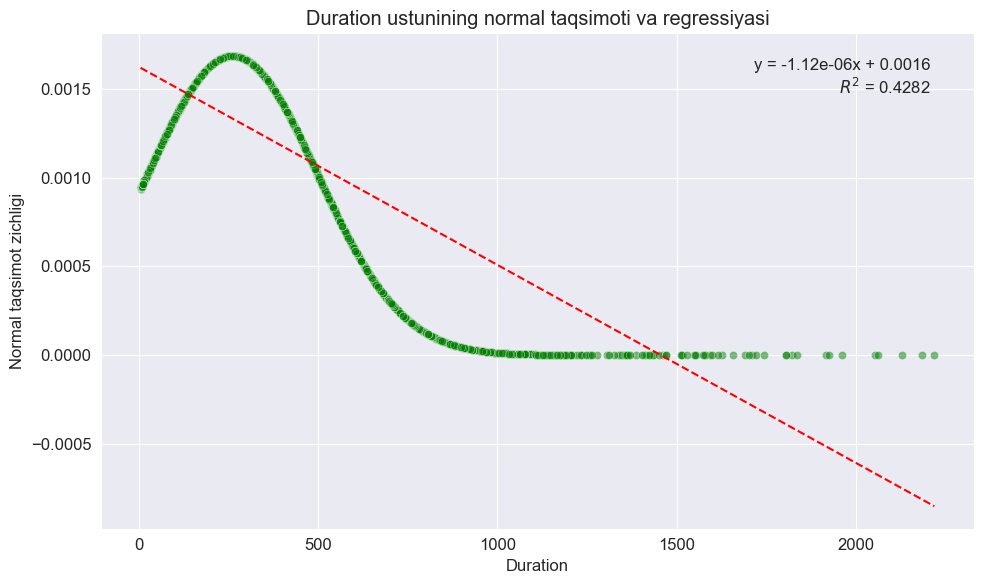

In [192]:
# 1. Параметры нормального распределения
mean = df['duration'].mean()
std_dev = df['duration'].std()

# 2. Плотность вероятности
normal_pdf = norm.pdf(df['duration'], mean, std_dev)

# 3. Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['duration'], y=normal_pdf, color='green', alpha=0.5)

# 4. Линейная регрессия
model = LinearRegression()
X = df[['duration']]
y = normal_pdf
model.fit(X, y)

coef = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

# 5. Линия регрессии
x_vals = np.linspace(df['duration'].min(), df['duration'].max(), 1000)
y_vals = coef * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', linestyle='--')

# 6. Формула — ПРАВЫЙ ВЕРХНИЙ УГОЛ
formula = f'y = {coef:.2e}x + {intercept:.4f}\n$R^2$ = {r_squared:.4f}'
plt.text(0.95, 0.95, formula, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='right')

# 7. Оформление
plt.title('Duration ustunining normal taqsimoti va regressiyasi')
plt.xlabel('Duration')
plt.ylabel('Normal taqsimot zichligi')
plt.grid(True)
plt.tight_layout()
plt.show()

Quyidagi grafikda duration ustunining taqsimoti va unga mos regressiya chizig‘i ko‘rsatilgan. Ma’lumotlar normal taqsimot zichligiga nisbatan teng taqsimlanmagan: zichlik egri chizig‘i notekis va asimmetrik bo‘lib, yuqori zichlik qisqa suhbatlarga (taxminan 200–400 soniya) to‘g‘ri keladi. Qizil chiziq — bu ushbu zichlik ustiga qurilgan chiziqli regressiya bo‘lib, $R^2 = 0.4282$ qiymati chiziqli bog‘liqlik zaifligini bildiradi. Bu shuni ko‘rsatadiki, suhbat uzunligi va taqsimot zichligi orasida to‘g‘ridan-to‘g‘ri kuchli bog‘liqlik yo‘q. Bu natija duration o‘zgaruvchisi normal taqsimotga yaqin emasligini va tahlilda ehtiyotkorlik bilan foydalanishni talab qilishini ko‘rsatadi.

### B.P3 — Chiziqli regressiya asosida tahlil

Ushbu bosqichda `duration` va `deposit` o‘rtasidagi bog‘liqlik chiziqli regressiya modeli yordamida tahlil qilinadi. Regressiya tenglamasi quriladi, korrelyatsiya koeffitsienti (Pearson r) va determinatsiya koeffitsienti (R²) hisoblanadi. Olingan natijalar orqali duration va deposit o‘rtasidagi munosabat kuchi va yo‘nalishi aniqlanadi. Ma’lumotlar asosida nuqtalar tarqalish diagrammasi (Scatter Plot) va regressiya chizig‘i quriladi.


Chiziqli regressiya tenglamasi: y = 0.411335x + 1401.469434
Determinatsiya koeffitsienti (R²): 0.0013
Korrelyatsiya koeffitsienti (Pearson r): 0.0367


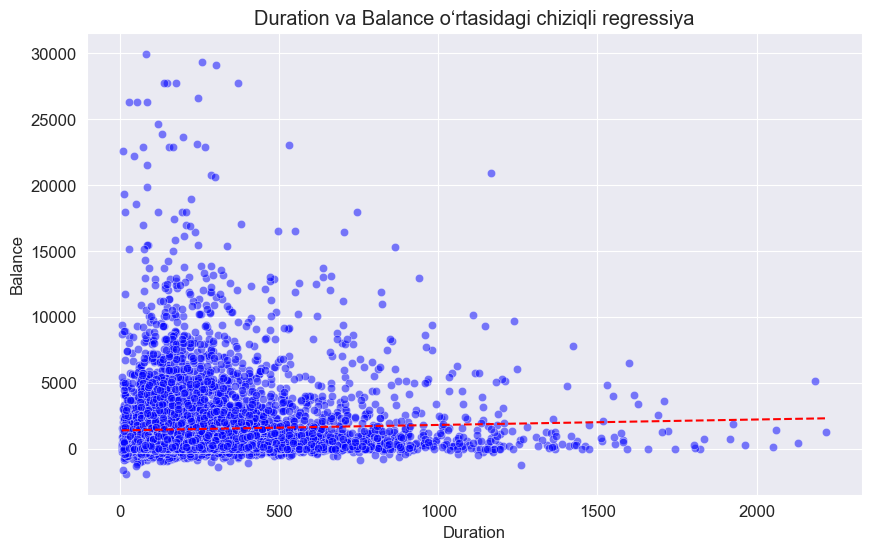

In [193]:
# Chiziqli regressiya va korrelyatsiya
X = df['duration']
y = df['balance']

# Pearson korrelyatsiya koeffitsienti
korrelyatsiya = np.corrcoef(X, y)[0, 1]

# Regressiya tenglamasi koeffitsientlari
mean_X = X.mean()
mean_y = y.mean()
std_X = X.std()
std_y = y.std()

koef = korrelyatsiya * (std_y / std_X)
intersept = mean_y - koef * mean_X
r_kvadrat = korrelyatsiya ** 2

print(f"Chiziqli regressiya tenglamasi: y = {koef:.6f}x + {intersept:.6f}")
print(f"Determinatsiya koeffitsienti (R²): {r_kvadrat:.4f}")
print(f"Korrelyatsiya koeffitsienti (Pearson r): {korrelyatsiya:.4f}")

# Scatter plot va regressiya chizig‘i
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, color='blue', alpha=0.5)

x_values = np.linspace(X.min(), X.max(), 100)
y_values = koef * x_values + intersept
plt.plot(x_values, y_values, color='red', linestyle='--')

plt.title('Duration va Balance o‘rtasidagi chiziqli regressiya')
plt.xlabel('Duration')
plt.ylabel('Balance')
plt.grid(True)
plt.show()


Quyidagi grafikda duration (suhbat davomiyligi) va balance (mijoz hisobidagi mablag‘) o‘rtasidagi bog‘liqlik tahlil qilingan. Chiziqli regressiya tenglamasi: y = 0.411335x + 1401.469434, bu shuni anglatadiki, suhbat davomiyligi ortishi bilan balans ham biroz oshadi. Biroq determinatsiya koeffitsienti (R² = 0.0013) va Pearson korrelyatsiya koeffitsienti (r = 0.0367) juda past bo‘lib, bu o‘zgaruvchilar orasida deyarli hech qanday chiziqli bog‘liqlik yo‘qligini ko‘rsatadi. Shu sababli, duration mijozning moliyaviy faolligini (balance) prognozlashda foydali indikator emas.

# B.M2 — Kengaytirilgan statistik tahlil: kvartillar va taqsimot ko‘rsatkichlari

Ushbu bosqichda `duration` va `deposit` ustunlari bo‘yicha qo‘shimcha statistik ko‘rsatkichlar hisoblanadi. Birinchi kvartil (Q1), uchinchi kvartil (Q3), interkvartil farq (IQR) va 90-foizlik pertsentil (P90) aniqlanadi. Ma’lumotlarning tarqalishini va o‘zgaruvchanlik darajasini baholash uchun `deposit` ustuni uchun boxplot (quti va mo‘ylovlar diagrammasi) chiziladi. Tahlil natijalari ma’lumotlar ichidagi outlierlar (chegaradan chiqib ketuvchi qiymatlar) mavjudligini aniqlash imkonini beradi.



duration ustuni uchun kengaytirilgan statistik ko'rsatkichlar:
 - 1-kvartil (Q1): 113.0000
 - 3-kvartil (Q3): 324.0000
 - Interkvartil farq (IQR): 211.0000
 - 90-foizlik pertsentil (P90): 532.0000

balance ustuni uchun kengaytirilgan statistik ko'rsatkichlar:
 - 1-kvartil (Q1): 162.0000
 - 3-kvartil (Q3): 1730.0000
 - Interkvartil farq (IQR): 1568.0000
 - 90-foizlik pertsentil (P90): 3954.0000


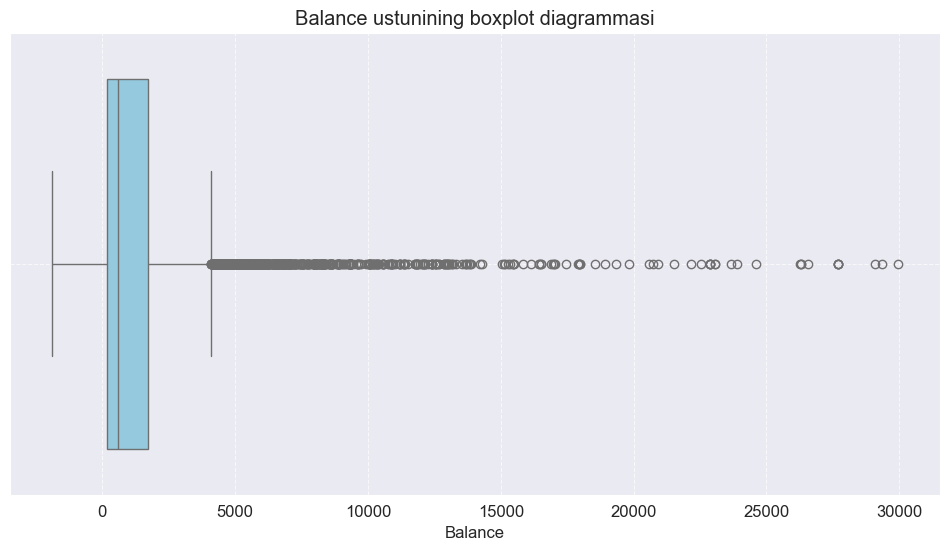

In [194]:
ustunlar = ['duration', 'balance']

for ustun in ustunlar:
    q1 = df[ustun].quantile(0.25)
    q3 = df[ustun].quantile(0.75)
    iqr = q3 - q1
    p90 = df[ustun].quantile(0.90)

    print(f"\n{ustun} ustuni uchun kengaytirilgan statistik ko'rsatkichlar:")
    print(f" - 1-kvartil (Q1): {q1:.4f}")
    print(f" - 3-kvartil (Q3): {q3:.4f}")
    print(f" - Interkvartil farq (IQR): {iqr:.4f}")
    print(f" - 90-foizlik pertsentil (P90): {p90:.4f}")

# Boxplot (Deposit uchun)
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['balance'], orient='h', color='skyblue')
plt.title('Balance ustunining boxplot diagrammasi')
plt.xlabel('Balance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Quyidagi kengaytirilgan statistik tahlil natijalari duration va balance ustunlari uchun ma’lumotlarning taqsimotini chuqurroq tushunishga yordam beradi. Duration ustuni bo‘yicha 1-kvartil 113 sekund, 3-kvartil esa 324 sekund bo‘lib, interkvartil farq (IQR) 211 sekundni tashkil etadi. Bu, suhbatlarning asosiy qismi aynan shu oraliqda sodir bo‘lishini anglatadi. 90-foizlik pertsentil 532 ga teng, ya’ni faqat 10% suhbatlar bundan uzunroq davom etadi. Balance ustunida esa IQR ancha katta (1568), bu esa balans qiymatlarining kuchli tarqoq ekanini bildiradi. Ayniqsa, 90-foizlik pertsentil (3954 EUR) yuqoriligi hisobda juda katta mablag‘lar bo‘lishi mumkinligini ko‘rsatadi. Boxplot diagrammasi orqali ushbu farqlarni vizual tarzda ko‘rish mumkin. Bu tahlil bank uchun yuqori balansli mijozlarni aniqlash va ularni nishonga olish strategiyasini ishlab chiqishda muhimdir.

# B.M3 — Duration va Deposit o‘rtasidagi korrelyatsiya

Ushbu bosqichda `duration` va `deposit` ustunlari o‘rtasidagi bog‘liqlikni baholash uchun Pearson korrelyatsiya koeffitsienti hisoblanadi. Bu koeffitsient ikki o‘zgaruvchi orasidagi chiziqli munosabat kuchini ko‘rsatadi. Quyida ushbu bog‘liqlikni vizual tarzda ko‘rsatish uchun nuqtalar tarqalish diagrammasi (scatter plot) keltirilgan.


Duration va Balance o‘rtasidagi Pearson korrelyatsiya koeffitsienti: 0.0367


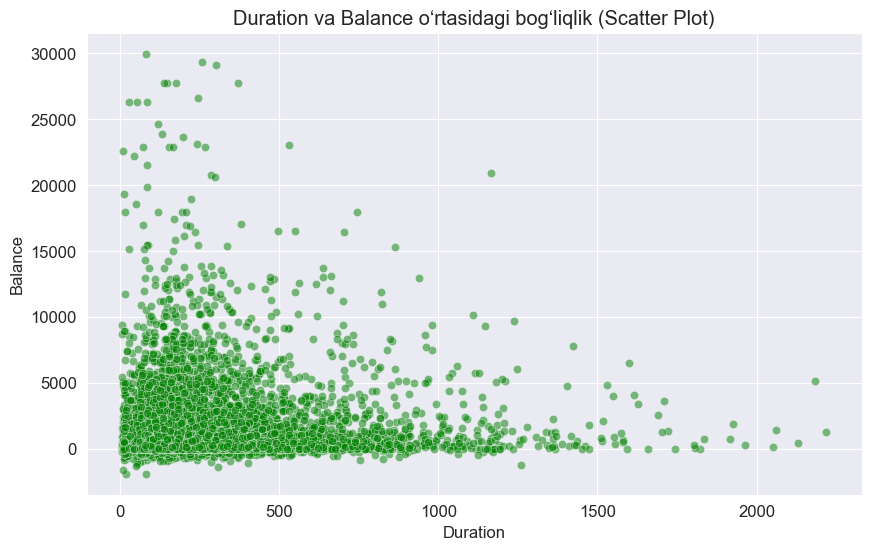

In [195]:
# Duration va Deposit o‘rtasidagi korrelyatsiya
X = df['duration']
y = df['balance']

korrelyatsiya = np.corrcoef(X, y)[0, 1]

print(f"Duration va Balance o‘rtasidagi Pearson korrelyatsiya koeffitsienti: {korrelyatsiya:.4f}")

# Scatter plot (faqat korrelyatsiyani ko‘rsatish uchun, regressiyasiz)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, color='green', alpha=0.5)
plt.title('Duration va Balance o‘rtasidagi bog‘liqlik (Scatter Plot)')
plt.xlabel('Duration')
plt.ylabel('Balance')
plt.grid(True)
plt.show()


Quyidagi scatter plot va hisoblangan korrelyatsiya natijalari duration va balance o‘rtasidagi bog‘liqlikning deyarli yo‘qligini ko‘rsatadi. Pearson korrelyatsiya koeffitsienti atigi 0.0367 ga teng bo‘lib, bu ikkala o‘zgaruvchining orasida juda zaif, statistik ahamiyatsiz munosabat borligini anglatadi. Scatter plotda nuqtalar tasodifiy tarqalgan bo‘lib, hech qanday aniq tendensiya yoki chiziqli aloqa kuzatilmaydi. Bu shuni ko‘rsatadiki, mijozning hisobdagi balans miqdori u bilan bo‘lgan suhbat davomiyligiga bevosita bog‘liq emas. Bu fakt, suhbatning davomiyligini oshirish orqali mijoz balansiga ta’sir qilish mumkin emasligini bildiradi.

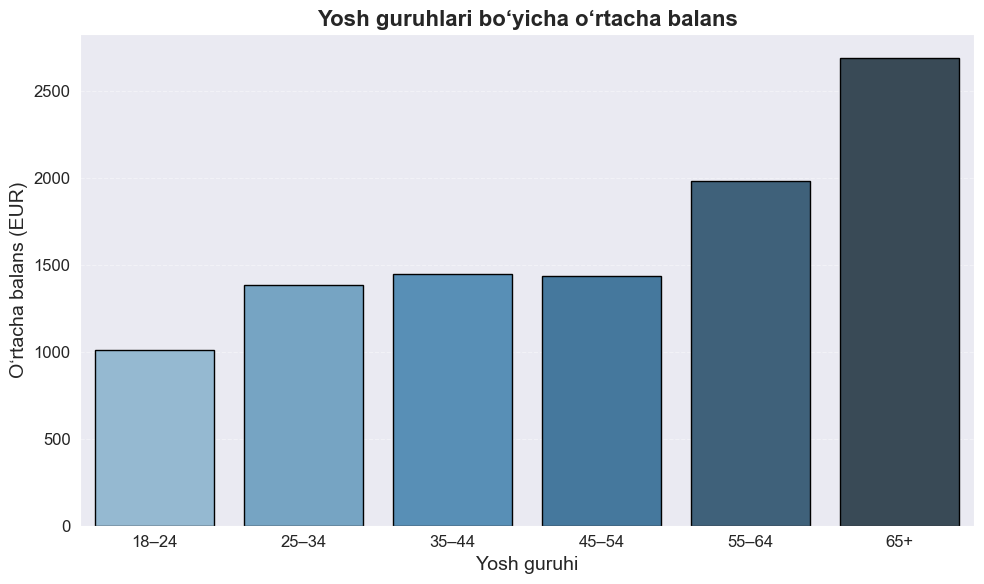

Yosh guruhlari bo‘yicha o‘rtacha balans:
  yosh_guruhi   balans
1       18–24  1009.47
2       25–34  1380.89
3       35–44  1449.17
4       45–54  1433.81
5       55–64  1983.59
6         65+  2688.37


In [196]:
# Savol 1:
# Qaysi yosh guruhlari balans miqdori bo‘yicha eng yuqori moliyaviy faollikni ko‘rsatmoqda?
# Bu holat bankning marketing strategiyasiga qanday ta’sir qilishi mumkin?

# 1. Vaqtinchalik yosh guruhlarini yaratish (df ga saqlanmaydi)
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
temp_age_group = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# 2. Har bir guruh bo‘yicha o‘rtacha balansni hisoblash
age_balance = df.groupby(temp_age_group, observed=True)['balance'].mean().reset_index()
age_balance.columns = ['yosh_guruhi', 'balans']

# 3. Vizualizatsiya
plt.figure(figsize=(10, 6))
sns.barplot(data=age_balance, x='yosh_guruhi', y='balans', hue='yosh_guruhi',
            palette='Blues_d', legend=False, edgecolor='black')

plt.title('Yosh guruhlari bo‘yicha o‘rtacha balans', fontsize=16, weight='bold')
plt.xlabel('Yosh guruhi', fontsize=14)
plt.ylabel('O‘rtacha balans (EUR)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 4. Jadval
print("Yosh guruhlari bo‘yicha o‘rtacha balans:")
print(
    age_balance.round(2)
    .reset_index(drop=True)
    .set_index(pd.Index(range(1, len(age_balance)+1)))
)

Quyidagi natijalar yosh guruhlari bo‘yicha mijozlarning moliyaviy faolligini aks ettiradi. Eng past o‘rtacha balans 18–24 yoshdagi mijozlarda (1009.47 EUR) kuzatilgan bo‘lsa, eng yuqori ko‘rsatkich 65 yoshdan kattalarda (2688.37 EUR) qayd etilgan. Bu shuni anglatadiki, yoshi katta mijozlar bank hisobida ko‘proq mablag‘ saqlashga moyil. Shuningdek, 55–64 yosh oralig‘idagi mijozlar ham sezilarli darajada yuqori balansga ega (1983.59 EUR). Ushbu tendensiya bankka marketing strategiyasini yoshi kattaroq segmentga qaratishga sabab bo‘lishi mumkin, chunki ular moliyaviy jihatdan barqarorroq va balans miqdori yuqori bo‘lgan mijozlardir.

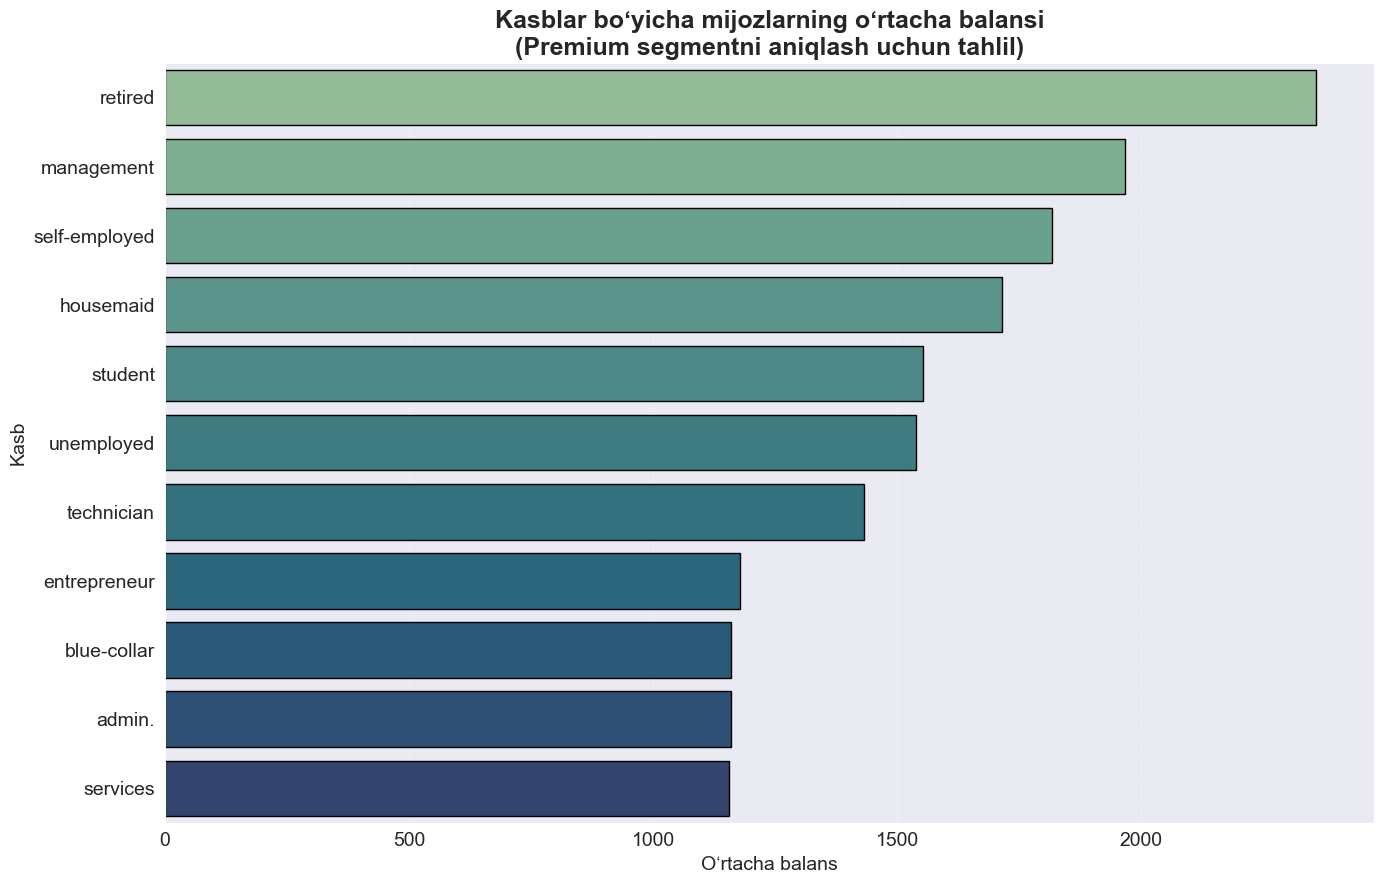

Kasblar bo‘yicha o‘rtacha balans (kamayish tartibida):
              job  balance
1         retired  2358.58
2      management  1965.90
3   self-employed  1817.10
4       housemaid  1714.35
5         student  1552.29
6      unemployed  1538.73
7      technician  1431.37
8    entrepreneur  1177.69
9     blue-collar  1160.51
10         admin.  1160.05
11       services  1156.52


In [197]:
# Savol 2:
# Mijozlarning kasblari bo‘yicha balans darajasi qanday taqsimlangan?
# Qaysi kasb egalari premium bank mahsulotlari uchun istiqbolli segment hisoblanadi?

# 1. O‘rtacha balansni kasb bo‘yicha hisoblash
job_balance = (
    df.groupby('job', observed=True)['balance']
    .mean()
    .reset_index()
    .sort_values(by='balance', ascending=False)
)

# 2. Vizualizatsiya
plt.figure(figsize=(14, 9))
sns.barplot(
    data=job_balance,
    x='balance',
    y='job',
    hue='job',
    legend=False,
    palette='crest',
    edgecolor='black'
)

plt.title(
    'Kasblar bo‘yicha mijozlarning o‘rtacha balansi\n(Premium segmentni aniqlash uchun tahlil)',
    fontsize=18,
    weight='bold'
)
plt.xlabel('O‘rtacha balans', fontsize=14)
plt.ylabel('Kasb', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 3. Jadval ko‘rinishida natijalar
print("Kasblar bo‘yicha o‘rtacha balans (kamayish tartibida):")
print(
    job_balance.round(2)
    .reset_index(drop=True)
    .set_index(pd.Index(range(1, len(job_balance)+1)))
)

Kasblar bo‘yicha o‘rtacha balans qiymatlari tahlili shuni ko‘rsatadiki, eng yuqori moliyaviy faollik nafaqadagi (retired) va boshqaruv (management) sohalarida kuzatiladi. Shu bilan birga, self-employed, housemaid va student toifalari ham yuqori o‘rtacha balansga ega. Aksincha, services, admin. va blue-collar kabi kasblar pastroq balans ko‘rsatkichlariga ega. Bu natijalar bankka qaysi kasb egalari uchun premium moliyaviy mahsulotlar tavsiya etilishi mumkinligini aniqlashda muhim rol o‘ynaydi.

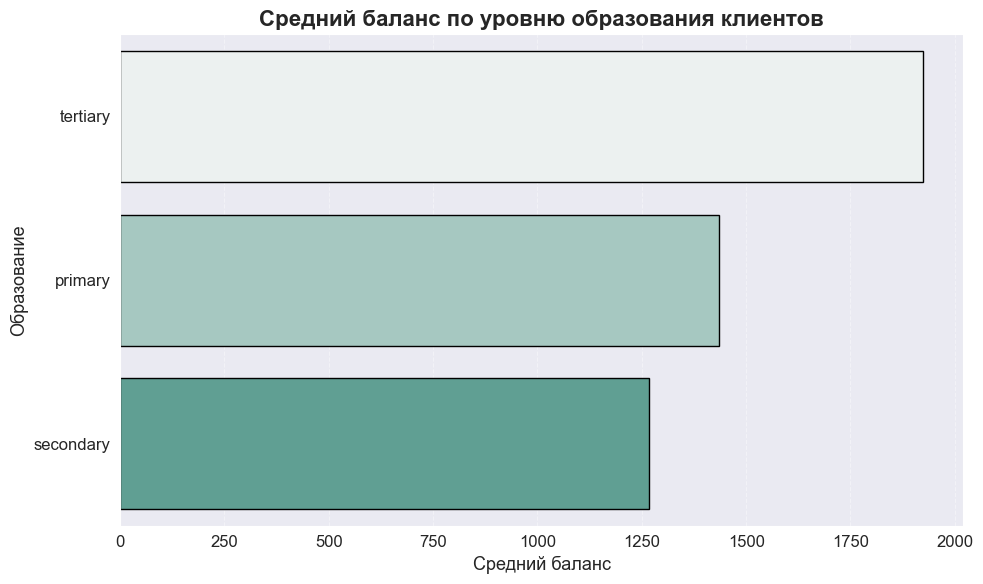

Средний баланс по уровням образования:
education  balance
 tertiary  1924.00
  primary  1434.20
secondary  1266.73


In [198]:
# Вопрос 3:
# Как уровень образования влияет на средний баланс клиентов,
# и какие категории образования являются наиболее финансово активными?
#
# Цель — понять, какие группы по уровню образования в среднем хранят больше средств на счетах.
# Это позволит банку адаптировать подходы к предложению продуктов в зависимости от образовательного уровня клиента.

# 1. Группировка по уровню образования
edu_balance = df.groupby('education', observed=True)['balance'].mean().reset_index()
edu_balance = edu_balance.sort_values(by='balance', ascending=False)

# 2. Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(
    data=edu_balance,
    x='balance',
    y='education',
    hue='education',
    palette='light:#5A9',
    legend=False,
    edgecolor='black'
)

plt.title(
    'Средний баланс по уровню образования клиентов',
    fontsize=16,
    weight='bold'
)
plt.xlabel('Средний баланс', fontsize=13)
plt.ylabel('Образование', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Таблица
print("Средний баланс по уровням образования:")
print(edu_balance.round(2).to_string(index=False))

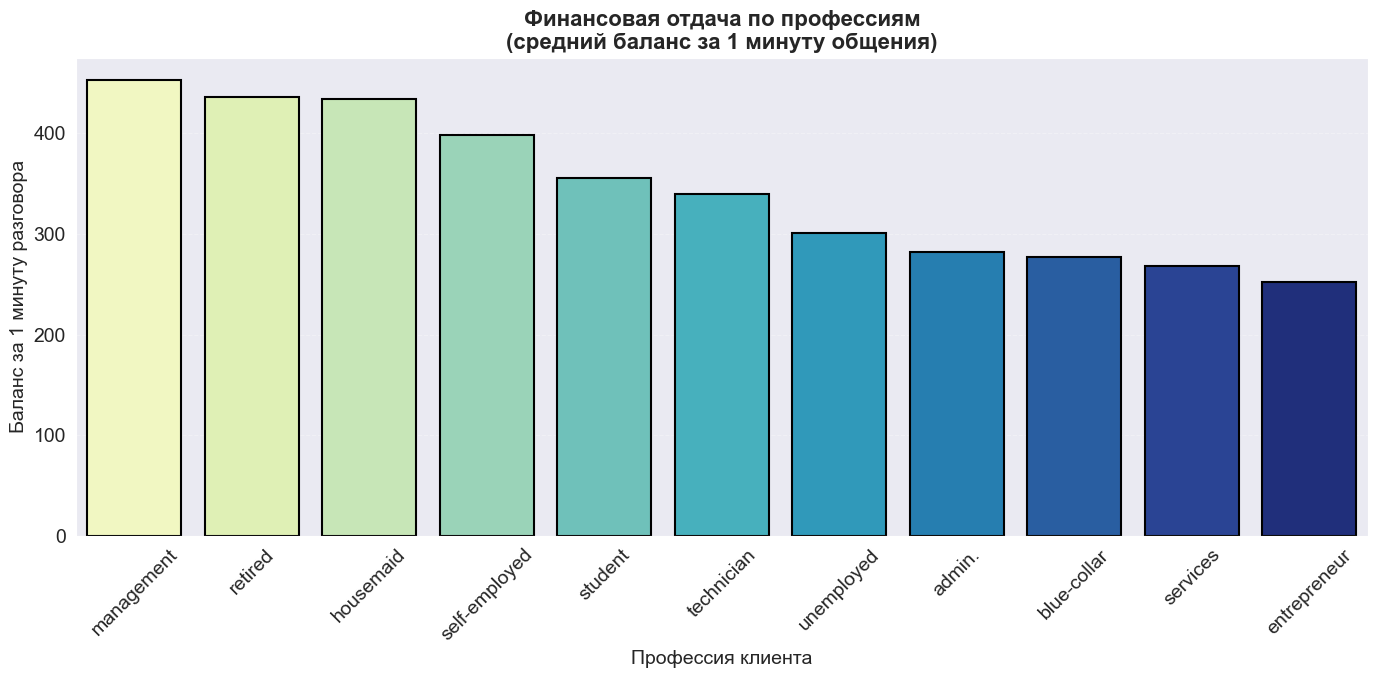

Финансовая отдача на 1 минуту общения по профессиям:
              job  balance  duration  efficiency_per_min
1      management  1965.90    260.82              452.24
2         retired  2358.58    325.04              435.38
3       housemaid  1714.35    236.97              434.08
4   self-employed  1817.10    274.01              397.89
5         student  1552.29    261.96              355.54
6      technician  1431.37    253.02              339.43
7      unemployed  1538.73    307.14              300.59
8          admin.  1160.05    246.73              282.10
9     blue-collar  1160.51    251.66              276.69
10       services  1156.52    259.08              267.83
11   entrepreneur  1177.69    279.92              252.44


In [199]:
# Вопрос 4:
# Какие профессии приносят банку наибольшую финансовую отдачу за каждую минуту общения?
# Какой клиентский сегмент наиболее рентабелен по отношению «баланс / длительность звонка»?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Установка глобального шрифта
plt.rcParams.update({'font.size': 14})

# 1. Расчёт эффективности по профессиям
job_eff = df.groupby('job', observed=True).agg({
    'balance': 'mean',
    'duration': 'mean'
}).reset_index()

job_eff['efficiency_per_min'] = job_eff['balance'] / (job_eff['duration'] / 60)
job_eff = job_eff.sort_values(by='efficiency_per_min', ascending=False)

# 2. Визуализация (ВЕРТИКАЛЬНО)
plt.figure(figsize=(14, 7))
sns.barplot(
    data=job_eff,
    x='job',
    y='efficiency_per_min',
    hue='job',
    legend=False,
    palette='YlGnBu',
    edgecolor='black',
    linewidth=1.5,
    saturation=0.9
)

plt.title('Финансовая отдача по профессиям\n(средний баланс за 1 минуту общения)', fontsize=16, weight='bold')
plt.xlabel('Профессия клиента', fontsize=14)
plt.ylabel('Баланс за 1 минуту разговора', fontsize=14)
plt.xticks(rotation=45, ha='center', fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Таблица (нумерация с 1)
print("Финансовая отдача на 1 минуту общения по профессиям:")
print(
    job_eff[['job', 'balance', 'duration', 'efficiency_per_min']]
    .round(2)
    .reset_index(drop=True)
    .set_index(pd.Index(range(1, len(job_eff)+1)))
)

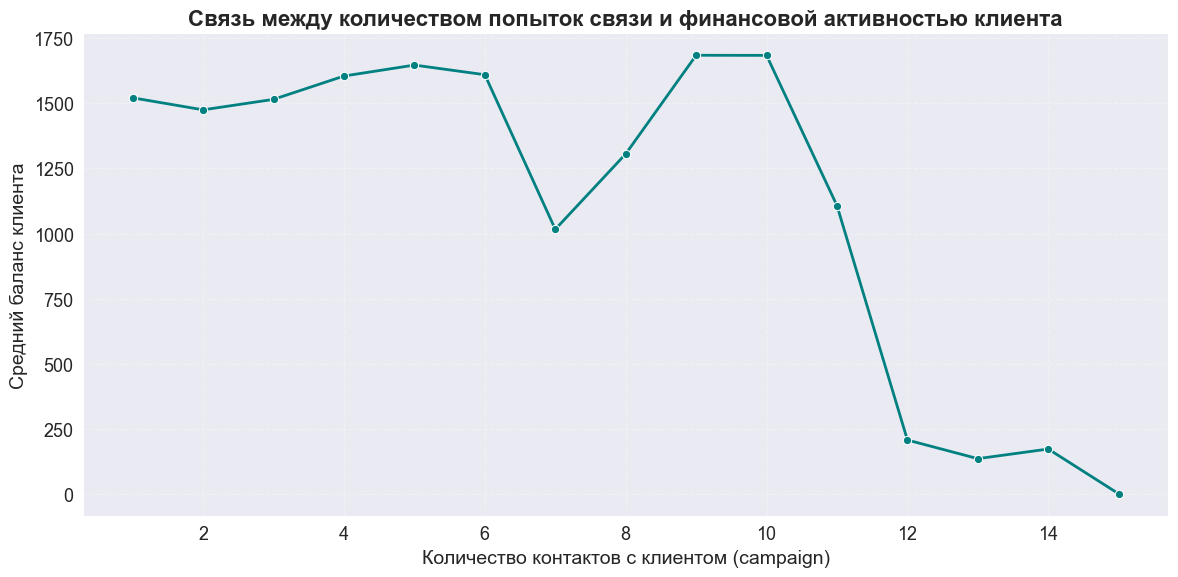

Средний баланс по числу попыток контакта (до 15):
 campaign  balance
        1  1521.32
        2  1475.12
        3  1515.42
        4  1605.08
        5  1647.12
        6  1610.03
        7  1016.11
        8  1305.79
        9  1684.83
       10  1684.40
       11  1107.00
       12   206.57
       13   135.00
       14   172.00
       15     0.00


In [200]:
# Вопрос 5:
# Как влияет количество попыток контакта с клиентом (campaign) на его финансовую активность?
# Есть ли предел, после которого эффективность повторных звонков снижается?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

# 1. Средний баланс по числу попыток связи
campaign_balance = df.groupby('campaign', observed=True)['balance'].mean().reset_index()

# 2. Ограничим до campaign ≤ 15
campaign_balance = campaign_balance[campaign_balance['campaign'] <= 15]

# 3. Визуализация: линия + точки
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=campaign_balance,
    x='campaign',
    y='balance',
    marker='o',
    color='teal',
    linewidth=2
)

plt.title('Связь между количеством попыток связи и финансовой активностью клиента',
          fontsize=16, weight='bold')
plt.xlabel('Количество контактов с клиентом (campaign)', fontsize=14)
plt.ylabel('Средний баланс клиента', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Таблица
print("Средний баланс по числу попыток контакта (до 15):")
print(campaign_balance.round(2).to_string(index=False))

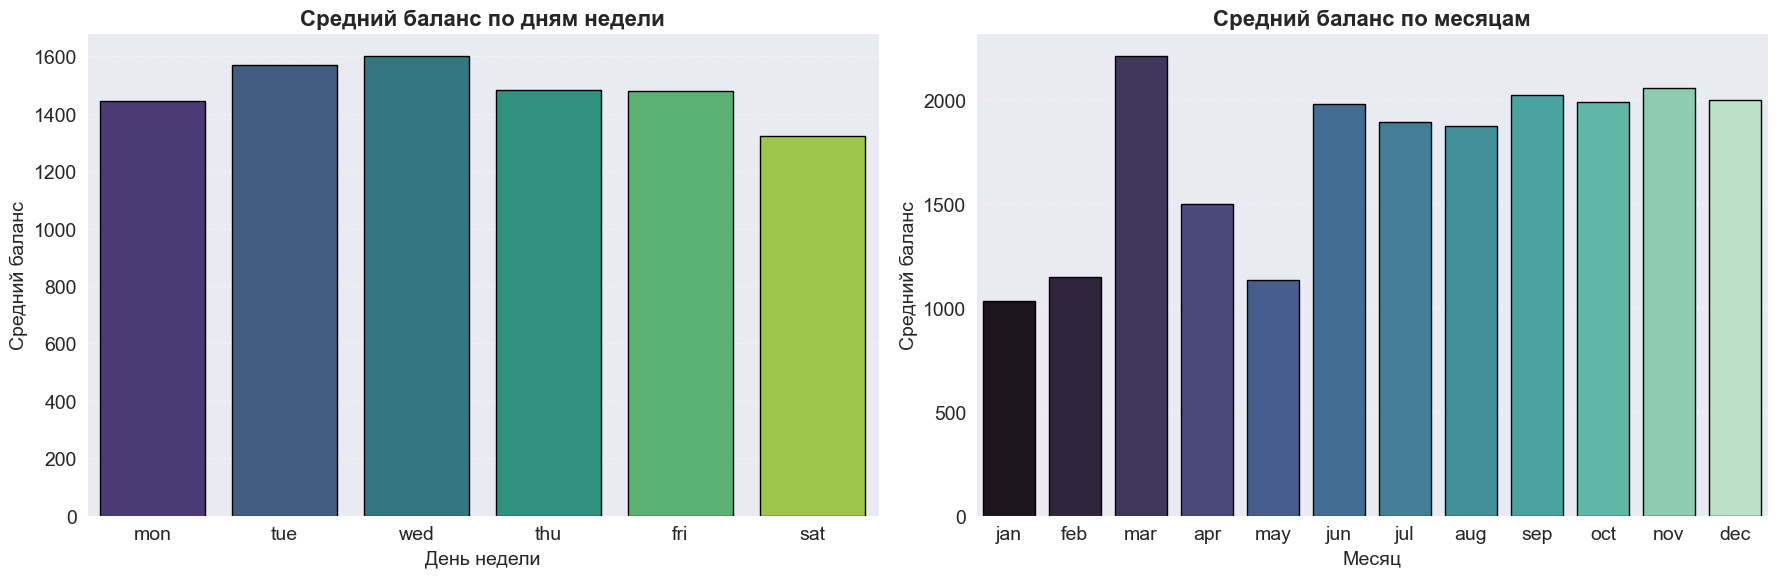

Средний баланс по дням недели:
  weekday  balance
1     mon  1444.19
2     tue  1569.40
3     wed  1600.04
4     thu  1482.77
5     fri  1477.73
6     sat  1324.00

Средний баланс по месяцам:
   month  balance
1    jan  1034.06
2    feb  1147.33
3    mar  2210.17
4    apr  1497.29
5    may  1133.65
6    jun  1978.52
7    jul  1892.63
8    aug  1875.29
9    sep  2025.51
10   oct  1992.13
11   nov  2056.66
12   dec  2000.04


In [201]:
# Вопрос 6:
# В какие дни недели и месяцы звонки оказываются наиболее результативными
# с точки зрения финансовой активности клиента?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

# --- Средний баланс по дням недели (включая субботу) ---
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat']
day_balance = df.groupby('weekday', observed=True)['balance'].mean().reset_index()
day_balance['weekday'] = pd.Categorical(day_balance['weekday'], categories=day_order, ordered=True)
day_balance = day_balance.sort_values('weekday')

# --- Средний баланс по месяцам (через временную колонку month_name_temp) ---
month_name_temp = df['date'].dt.strftime('%b').str.lower()
month_balance = (
    df.assign(month_name_temp=month_name_temp)
    .groupby('month_name_temp', observed=True)['balance']
    .mean()
    .reset_index()
)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_balance['month_name_temp'] = pd.Categorical(month_balance['month_name_temp'], categories=month_order, ordered=True)
month_balance = month_balance.sort_values('month_name_temp')

# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График по дням недели
sns.barplot(
    data=day_balance,
    x='weekday',
    y='balance',
    hue='weekday',
    palette='viridis',
    legend=False,
    ax=axes[0],
    edgecolor='black'
)
axes[0].set_title('Средний баланс по дням недели', fontsize=16, weight='bold')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Средний баланс')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# График по месяцам
sns.barplot(
    data=month_balance,
    x='month_name_temp',
    y='balance',
    hue='month_name_temp',
    palette='mako',
    legend=False,
    ax=axes[1],
    edgecolor='black'
)
axes[1].set_title('Средний баланс по месяцам', fontsize=16, weight='bold')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Средний баланс')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Таблицы ---
print("Средний баланс по дням недели:")
print(
    day_balance.round(2)
    .reset_index(drop=True)
    .set_index(pd.Index(range(1, len(day_balance) + 1)))
)

print("\nСредний баланс по месяцам:")
print(
    month_balance.round(2)
    .rename(columns={'month_name_temp': 'month'})
    .reset_index(drop=True)
    .set_index(pd.Index(range(1, len(month_balance) + 1)))
)

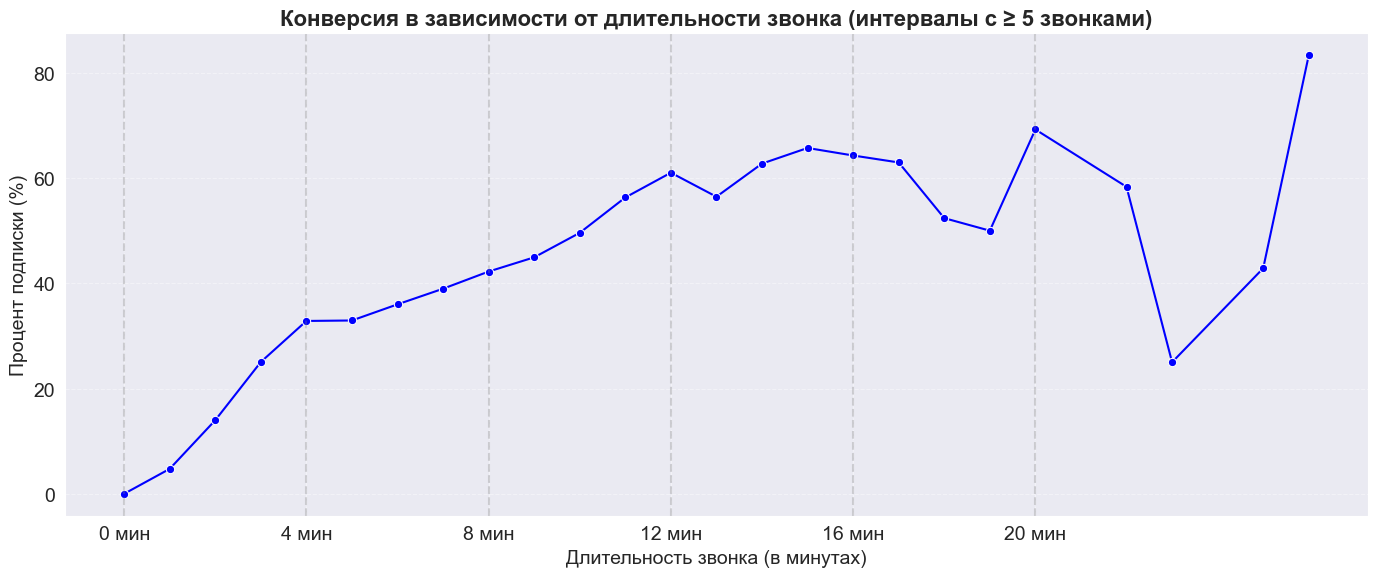

In [202]:
# Вопрос 7:
# Как длительность звонка влияет на вероятность успешной подписки клиента?
# Существует ли минимальная эффективная длительность звонка, после которой шанс "да" резко растёт?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Интервалы по 1 минуте (60 секунд)
bin_width = 60
max_duration = int(df['duration'].max())
bins = range(0, max_duration + bin_width, bin_width)
df['duration_bin'] = pd.cut(df['duration'], bins=bins)

# 2. Подсчёт конверсии и количества звонков
conversion_by_duration = (
    df.groupby('duration_bin', observed=True)['y']
    .agg(
        conversion_rate=lambda x: (x == 'yes').mean() * 100,
        call_count='count'
    )
).reset_index()

# 3. Фильтруем: только интервалы с ≥ 5 звонками
conversion_by_duration = conversion_by_duration[conversion_by_duration['call_count'] >= 5]

# 4. Левая граница интервала в минутах
conversion_by_duration['minutes'] = [int(interval.left // 60) for interval in conversion_by_duration['duration_bin']]

# 5. Визуализация
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=conversion_by_duration,
    x='minutes',
    y='conversion_rate',
    marker='o',
    color='blue'
)

plt.title('Конверсия в зависимости от длительности звонка (интервалы с ≥ 5 звонками)', fontsize=16, weight='bold')
plt.xlabel('Длительность звонка (в минутах)')
plt.ylabel('Процент подписки (%)')

# Подписи и вертикальные линии каждые 4 минуты
xticks_to_show = [m for m in conversion_by_duration['minutes'] if m % 4 == 0]
plt.xticks(xticks_to_show, labels=[f'{m} мин' for m in xticks_to_show])

for m in xticks_to_show:
    plt.axvline(x=m, color='gray', linestyle='--', alpha=0.3)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 6. Очистка
df.drop(columns='duration_bin', inplace=True)

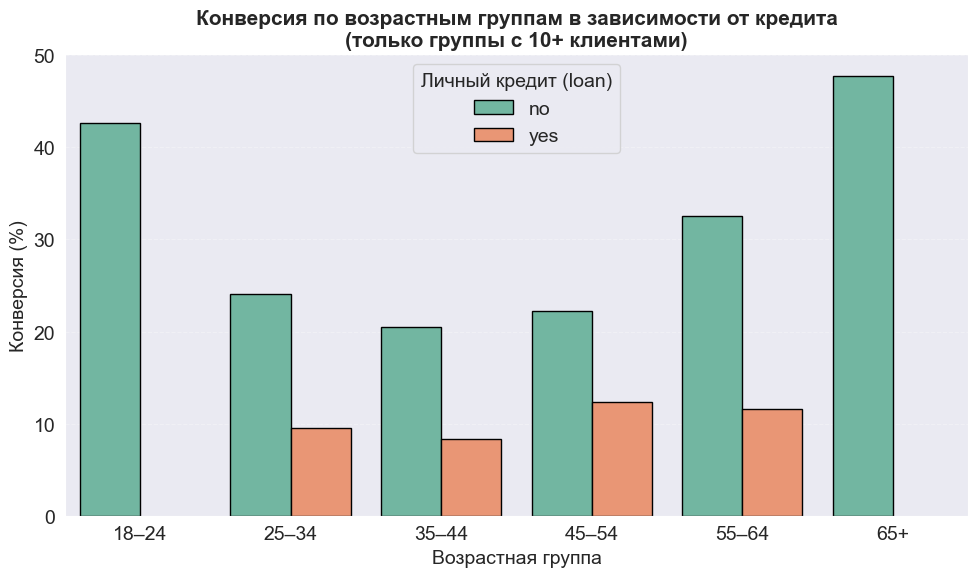

Конверсия по возрастным группам и статусу кредита (n ≥ 10):
  age_group_temp loan  signed  total  conversion_rate
0          18–24   no      64    150            42.67
1          25–34   no     544   2255            24.12
2          25–34  yes      33    347             9.51
3          35–44   no     457   2232            20.47
4          35–44  yes      30    360             8.33
5          45–54   no     263   1185            22.19
6          45–54  yes      33    268            12.31
7          55–64   no     216    663            32.58
8          55–64  yes      12    104            11.54
9            65+   no     125    262            47.71


In [203]:
# Вопрос 8:
# Какие возрастные группы наиболее склонны подписываться на депозит,
# и как наличие кредита влияет на это поведение?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Создаём временную переменную возрастной группы (НЕ сохраняется в df)
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
age_group_temp = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# 2. Добавляем её временно в копию df для анализа
df_temp = df.copy()
df_temp['age_group_temp'] = age_group_temp

# 3. Подсчёт подписавшихся и общего числа клиентов
conversion = (
    df_temp.groupby(['age_group_temp', 'loan'], observed=True)
    .agg(
        signed=('y', lambda x: (x == 'yes').sum()),
        total=('y', 'count')
    )
    .reset_index()
)

# 4. Вычисление конверсии (%)
conversion['conversion_rate'] = conversion['signed'] / conversion['total'] * 100

# 5. Фильтрация групп с минимум 10 клиентами
conversion = conversion[conversion['total'] >= 10]

# 6. Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(
    data=conversion,
    x='age_group_temp',
    y='conversion_rate',
    hue='loan',
    palette='Set2',
    edgecolor='black'
)

plt.title('Конверсия по возрастным группам в зависимости от кредита\n(только группы с 10+ клиентами)', fontsize=15, weight='bold')
plt.xlabel('Возрастная группа')
plt.ylabel('Конверсия (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Личный кредит (loan)')
plt.tight_layout()
plt.show()

# 7. Табличный вывод
print("Конверсия по возрастным группам и статусу кредита (n ≥ 10):")
print(
    conversion[['age_group_temp', 'loan', 'signed', 'total', 'conversion_rate']]
    .round(2)
    .reset_index(drop=True)
)

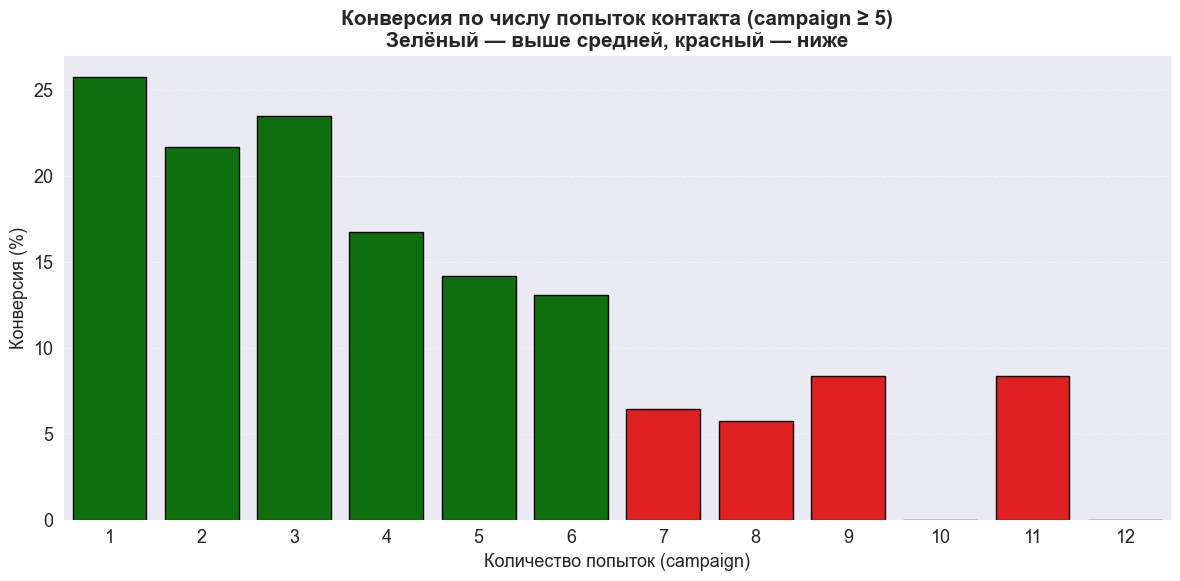

Конверсия по campaign (с цветовой маркировкой):
    campaign  total  yes_count  conversion_rate  color
0          1   3779        972            25.72  green
1          2   2179        472            21.66  green
2          3    869        204            23.48  green
3          4    406         68            16.75  green
4          5    247         35            14.17  green
5          6    153         20            13.07  green
6          7     93          6             6.45    red
7          8     52          3             5.77    red
8          9     24          2             8.33    red
9         10     10          0             0.00    red
10        11     12          1             8.33    red
11        12      7          0             0.00    red


In [204]:
# Вопрос 9:
# Сколько попыток контакта с клиентом (campaign) требуется для подписки?
# Отметим, при каком количестве попыток конверсия выше/ниже средней.


plt.rcParams.update({'font.size': 13})

# 1. Подсчёт по campaign
conversion_by_campaign = (
    df.groupby('campaign', observed=True)['y']
    .agg(
        total='count',
        yes_count=lambda x: (x == 'yes').sum()
    )
    .reset_index()
)

# 2. Конверсия в %
conversion_by_campaign['conversion_rate'] = (
    conversion_by_campaign['yes_count'] / conversion_by_campaign['total']
) * 100

# 3. Фильтр: только campaign, где ≥ 5 клиентов
conversion_by_campaign = conversion_by_campaign[conversion_by_campaign['total'] >= 5]

# 4. Средняя конверсия по всем
mean_conv = conversion_by_campaign['conversion_rate'].mean()

# 5. Создаём колонку с цветом
conversion_by_campaign['color'] = conversion_by_campaign['conversion_rate'].apply(
    lambda x: 'green' if x >= mean_conv else 'red'
)

# 6. palette как словарь: ключи должны быть ТИПА str
conversion_by_campaign['campaign_str'] = conversion_by_campaign['campaign'].astype(str)
palette_dict = dict(zip(conversion_by_campaign['campaign_str'], conversion_by_campaign['color']))

# 7. Визуализация с hue и palette
plt.figure(figsize=(12, 6))
sns.barplot(
    data=conversion_by_campaign,
    x='campaign_str',
    y='conversion_rate',
    hue='campaign_str',           # без этого не работает palette=словарь
    palette=palette_dict,
    legend=False,
    edgecolor='black'
)

plt.title('Конверсия по числу попыток контакта (campaign ≥ 5)\nЗелёный — выше средней, красный — ниже', fontsize=15, weight='bold')
plt.xlabel('Количество попыток (campaign)')
plt.ylabel('Конверсия (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 8. Таблица
print("Конверсия по campaign (с цветовой маркировкой):")
print(
    conversion_by_campaign[['campaign', 'total', 'yes_count', 'conversion_rate', 'color']]
    .round(2)
    .reset_index(drop=True)
)

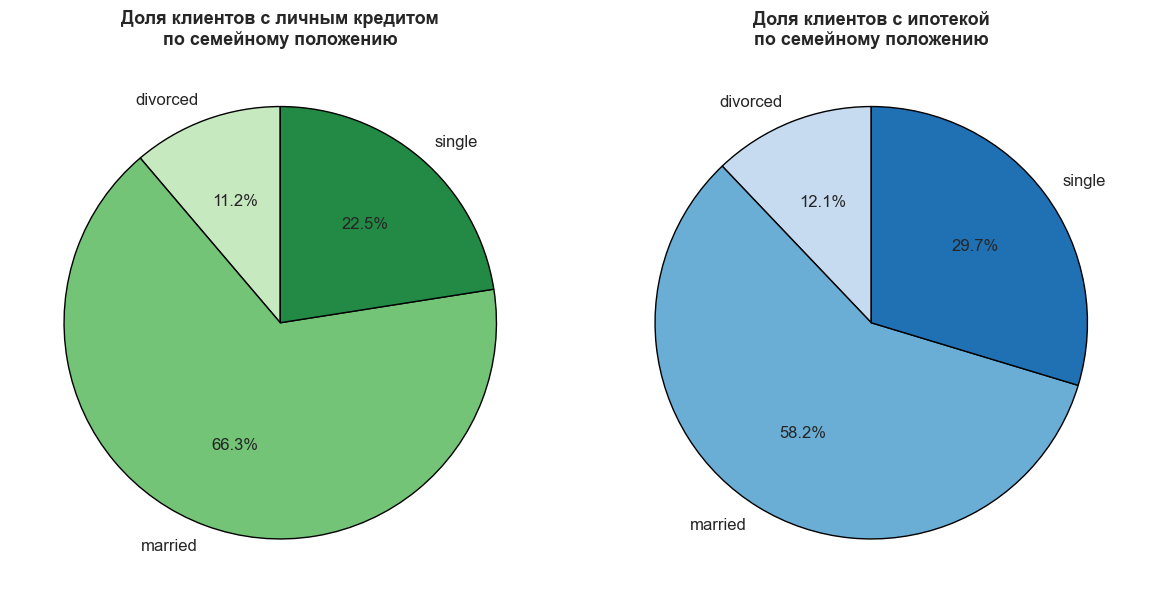

In [205]:
# Вопрос 10:
# Как семейное положение (marital) связано с наличием личных кредитов (loan) и ипотеки (housing)?

plt.rcParams.update({'font.size': 12})

# 1. Подсчёт % клиентов с кредитом по marital
loan_pie = (
    df[df['loan'] == 'yes']
    .groupby('marital', observed=True)
    .size()
    .reset_index(name='count')
)
loan_pie['percent'] = loan_pie['count'] / loan_pie['count'].sum() * 100

# 2. Подсчёт % клиентов с ипотекой по marital
housing_pie = (
    df[df['housing'] == 'yes']
    .groupby('marital', observed=True)
    .size()
    .reset_index(name='count')
)
housing_pie['percent'] = housing_pie['count'] / housing_pie['count'].sum() * 100

# 3. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Кредит (loan)
axes[0].pie(
    loan_pie['percent'],
    labels=loan_pie['marital'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Greens", len(loan_pie)),
    wedgeprops=dict(edgecolor='black')
)
axes[0].set_title('Доля клиентов с личным кредитом\nпо семейному положению', fontsize=13, weight='bold')

# --- Ипотека (housing)
axes[1].pie(
    housing_pie['percent'],
    labels=housing_pie['marital'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Blues", len(housing_pie)),
    wedgeprops=dict(edgecolor='black')
)
axes[1].set_title('Доля клиентов с ипотекой\nпо семейному положению', fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

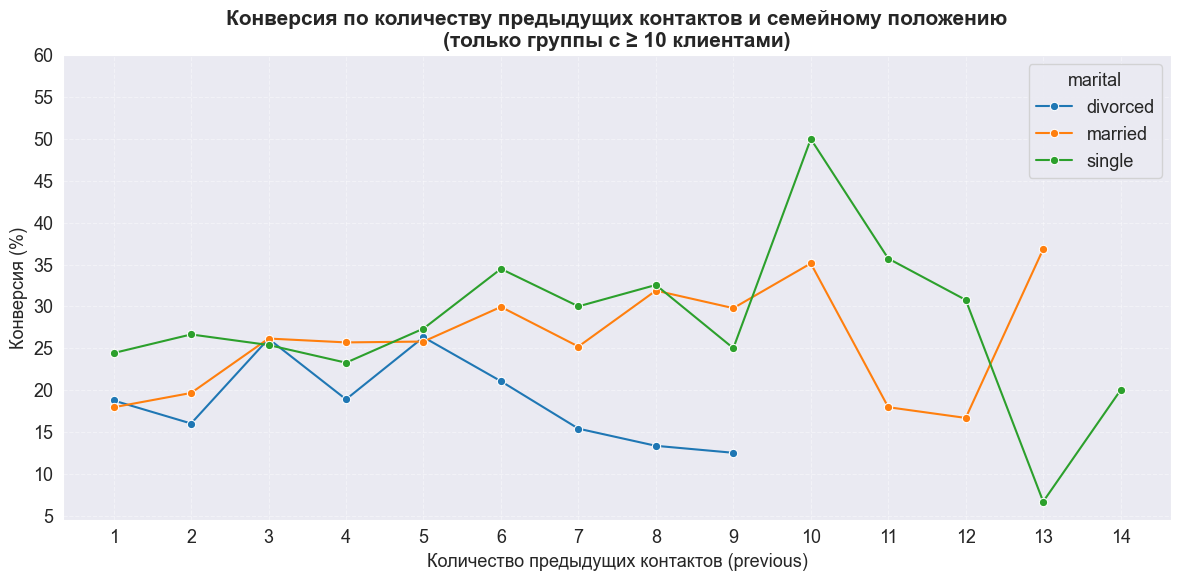

Конверсия по previous и marital (только группы с ≥ 10 наблюдений):
    previous   marital  total  yes_count  conversion_rate
0          1  divorced    304         57            18.75
1          1   married   1466        263            17.94
2          1    single    864        211            24.42
3          2  divorced    225         36            16.00
4          2   married   1145        225            19.65
5          2    single    608        162            26.64
6          3  divorced    111         29            26.13
7          3   married    650        170            26.15
8          3    single    327         83            25.38
9          4  divorced     90         17            18.89
10         4   married    397        102            25.69
11         4    single    202         47            23.27
12         5  divorced     57         15            26.32
13         5   married    252         65            25.79
14         5    single    128         35            27.34
15   

In [206]:
# Вопрос 11:
# Как семейное положение (marital) влияет на вероятность отклика клиента в зависимости
# от количества предыдущих контактов (previous)?
# Можно ли предположить, что у определённых категорий накопление прошлых попыток повышает шанс на подписку?

plt.rcParams.update({'font.size': 13})

# 1. Группировка по previous и marital
conversion_by_previous = (
    df.groupby(['previous', 'marital'], observed=True)['y']
    .agg(
        total='count',
        yes_count=lambda x: (x == 'yes').sum()
    )
    .reset_index()
)

# 2. Фильтрация: только группы с ≥ 10 наблюдениями
conversion_by_previous = conversion_by_previous[conversion_by_previous['total'] >= 10]

# 3. Расчёт конверсии (%)
conversion_by_previous['conversion_rate'] = (
    conversion_by_previous['yes_count'] / conversion_by_previous['total']
) * 100

# 4. Визуализация
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=conversion_by_previous.sort_values('previous'),
    x='previous',
    y='conversion_rate',
    hue='marital',
    marker='o'
)

plt.title('Конверсия по количеству предыдущих контактов и семейному положению\n(только группы с ≥ 10 клиентами)', fontsize=15, weight='bold')
plt.xlabel('Количество предыдущих контактов (previous)')
plt.ylabel('Конверсия (%)')
plt.grid(True, linestyle='--', alpha=0.4)

# Показываем каждое значение по оси X
x_vals = sorted(conversion_by_previous['previous'].unique())
plt.xticks(x_vals)

# Метки по Y: каждые 5 процентов
y_min = int(conversion_by_previous['conversion_rate'].min() // 5 * 5)
y_max = int(conversion_by_previous['conversion_rate'].max() // 5 * 5 + 10)
plt.yticks(range(y_min, y_max + 1, 5))

plt.tight_layout()
plt.show()

# 5. Таблица
print("Конверсия по previous и marital (только группы с ≥ 10 наблюдений):")
print(
    conversion_by_previous[['previous', 'marital', 'total', 'yes_count', 'conversion_rate']]
    .round(2)
    .reset_index(drop=True)
)

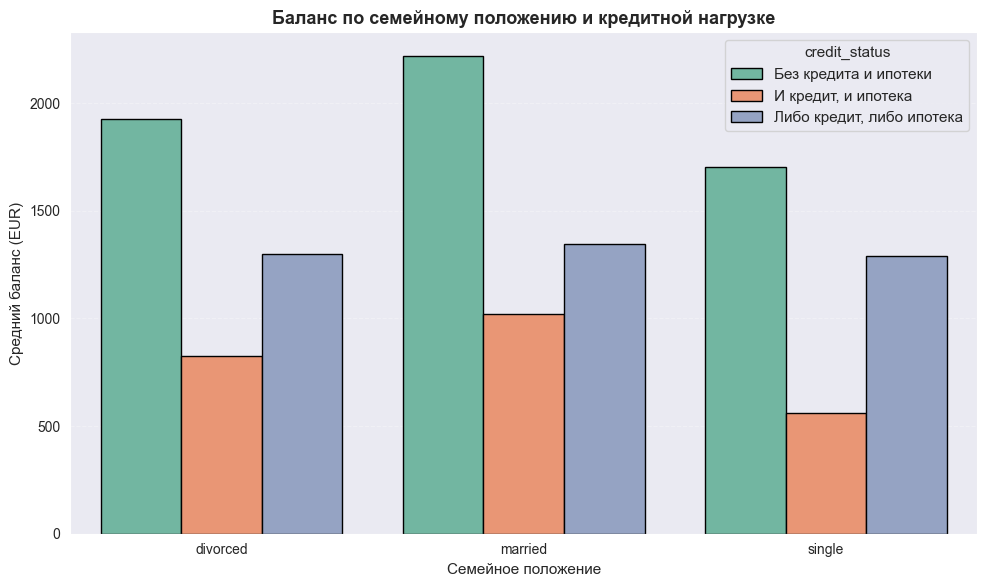

    marital              credit_status  balance
0  divorced      Без кредита и ипотеки  1926.48
1  divorced        И кредит, и ипотека   826.69
2  divorced  Либо кредит, либо ипотека  1299.83
3   married      Без кредита и ипотеки  2217.52
4   married        И кредит, и ипотека  1019.35
5   married  Либо кредит, либо ипотека  1343.80
6    single      Без кредита и ипотеки  1702.31
7    single        И кредит, и ипотека   560.62
8    single  Либо кредит, либо ипотека  1287.47


In [207]:
# Вопрос 12:
# Как семейное положение влияет на средний баланс в зависимости от кредитной нагрузки:
# без кредитов, либо одно, либо оба сразу?

plt.rcParams.update({'font.size': 11})  # уменьшенный шрифт

# Категории
df_temp = df.copy()
df_temp['credit_status'] = df_temp.apply(
    lambda row: 'И кредит, и ипотека' if row['loan'] == 'yes' and row['housing'] == 'yes'
    else ('Без кредита и ипотеки' if row['loan'] == 'no' and row['housing'] == 'no'
    else 'Либо кредит, либо ипотека'),
    axis=1
)

# Группировка
grouped = df_temp.groupby(['marital', 'credit_status'], observed=True)['balance'].mean().reset_index()

# График
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped,
    x='marital',
    y='balance',
    hue='credit_status',
    palette='Set2',
    edgecolor='black'
)
plt.title('Баланс по семейному положению и кредитной нагрузке', fontsize=13, weight='bold')
plt.xlabel('Семейное положение', fontsize=11)
plt.ylabel('Средний баланс (EUR)', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Таблица
print(grouped.round(2).reset_index(drop=True))

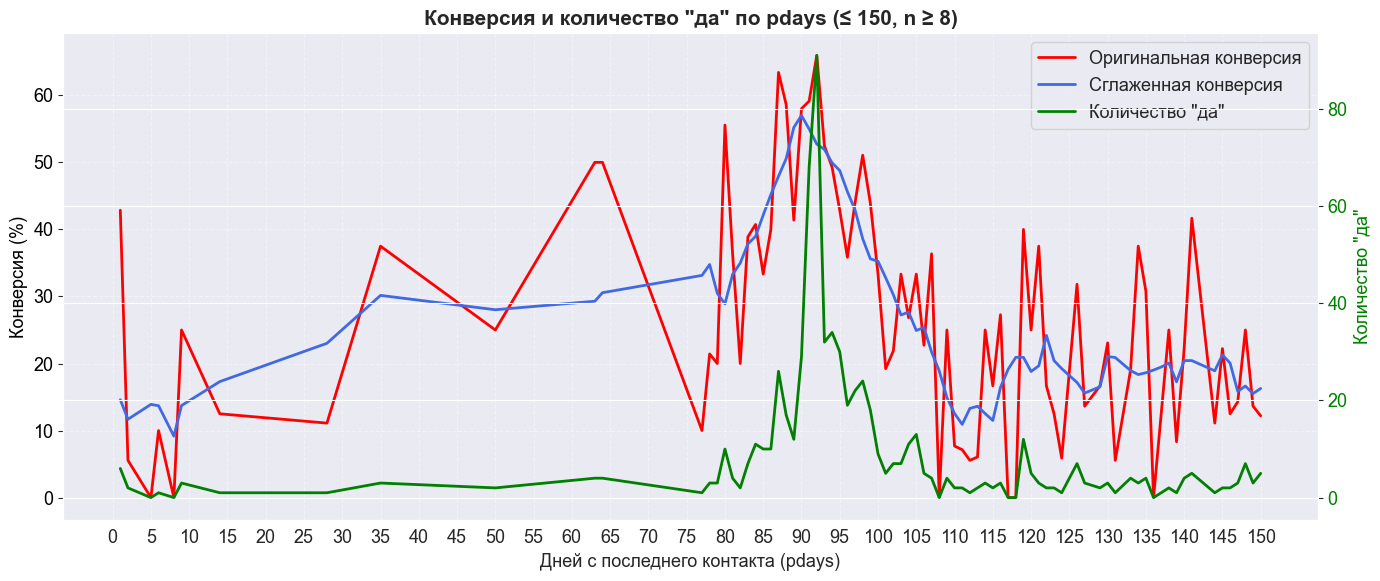

Конверсия по pdays (до 150, минимум 8 наблюдений):
    pdays  total  yes_count  conversion_rate  smoothed_rate
0       1     14          6            42.86          14.60
1       2     36          2             5.56          11.68
2       5     11          0             0.00          13.90
3       6     10          1            10.00          13.70
4       8     24          0             0.00           9.17
..    ...    ...        ...              ...            ...
76    146     16          2            12.50          20.06
77    147     21          3            14.29          15.85
78    148     28          7            25.00          16.64
79    149     22          3            13.64          15.52
80    150     41          5            12.20          16.28

[81 rows x 5 columns]


In [208]:
# Вопрос 13:
# Сколько времени (в днях — pdays) должно пройти с последнего контакта,
# чтобы повторная попытка была наиболее результативной?
# Есть ли “золотое окно” для повторного обращения?

plt.rcParams.update({'font.size': 13})

# 1. Группировка
conversion_by_pdays = (
    df.groupby('pdays', observed=True)['y']
    .agg(
        total='count',
        yes_count=lambda x: (x == 'yes').sum()
    )
    .reset_index()
)

# 2. Фильтрация: pdays ≤ 150 и минимум 8 клиентов
conversion_by_pdays = conversion_by_pdays[
    (conversion_by_pdays['pdays'] <= 150) &
    (conversion_by_pdays['total'] >= 8)
]

# 3. Метрики
conversion_by_pdays['conversion_rate'] = (
    conversion_by_pdays['yes_count'] / conversion_by_pdays['total']
) * 100
conversion_by_pdays['smoothed_rate'] = (
    conversion_by_pdays['conversion_rate']
    .rolling(window=7, center=True, min_periods=1)
    .mean()
).clip(lower=0)

# 4. Построение графика с двумя шкалами
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Левая ось: конверсия
sns.lineplot(
    data=conversion_by_pdays,
    x='pdays',
    y='conversion_rate',
    ax=ax1,
    color='red',
    label='Оригинальная конверсия',
    linewidth=2
)
sns.lineplot(
    data=conversion_by_pdays,
    x='pdays',
    y='smoothed_rate',
    ax=ax1,
    color='royalblue',
    label='Сглаженная конверсия',
    linewidth=2
)

ax1.set_ylabel('Конверсия (%)', color='black')
ax1.set_xlabel('Дней с последнего контакта (pdays)')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(range(0, 151, 5))
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Правая ось: количество "да", без дублирования в легенде
ax2 = ax1.twinx()
sns.lineplot(
    data=conversion_by_pdays,
    x='pdays',
    y='yes_count',
    ax=ax2,
    color='green',
    linewidth=2
)
ax2.set_ylabel('Количество "да"', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# --- Объединённая легенда
handles1, labels1 = ax1.get_legend_handles_labels()
custom_handle = plt.Line2D([0], [0], color='green', lw=2)
handles1.append(custom_handle)
labels1.append('Количество "да"')
ax1.legend(handles1, labels1, loc='upper right')

plt.title('Конверсия и количество "да" по pdays (≤ 150, n ≥ 8)', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

# 5. Таблица
print("Конверсия по pdays (до 150, минимум 8 наблюдений):")
print(
    conversion_by_pdays[['pdays', 'total', 'yes_count', 'conversion_rate', 'smoothed_rate']]
    .round(2)
    .reset_index(drop=True)
)

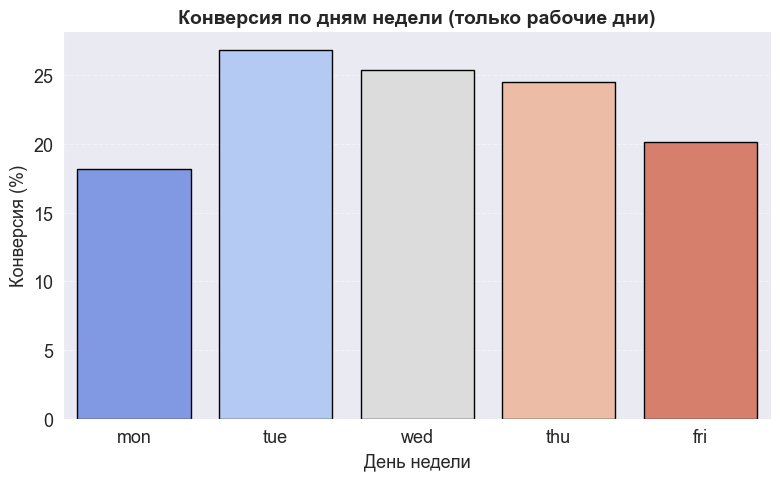

Конверсия по рабочим дням недели:
  weekday  total  yes_count  conversion_rate
0     mon   1711        311            18.18
1     tue   1300        349            26.85
2     wed   1420        360            25.35
3     thu   1780        436            24.49
4     fri   1623        327            20.15


In [209]:
# Вопрос 14:
# В какие дни недели (weekday) клиенты чаще всего соглашаются на подписку (y = 'yes')?
# Есть ли день, в который конверсия заметно выше?

plt.rcParams.update({'font.size': 13})

# 1. Группировка по дням недели
conversion_by_weekday = (
    df.groupby('weekday', observed=True)['y']
    .agg(
        total='count',
        yes_count=lambda x: (x == 'yes').sum()
    )
    .reset_index()
)

# 2. Конверсия в процентах
conversion_by_weekday['conversion_rate'] = (
    conversion_by_weekday['yes_count'] / conversion_by_weekday['total']
) * 100

# 3. Упорядочим только 5 рабочих дней
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
conversion_by_weekday = conversion_by_weekday[conversion_by_weekday['weekday'].isin(day_order)]
conversion_by_weekday['weekday'] = pd.Categorical(conversion_by_weekday['weekday'], categories=day_order, ordered=True)
conversion_by_weekday = conversion_by_weekday.sort_values('weekday')

# 4. Визуализация
plt.figure(figsize=(8, 5))
sns.barplot(
    data=conversion_by_weekday,
    x='weekday',
    y='conversion_rate',
    hue='weekday',
    palette='coolwarm',
    edgecolor='black',
    legend=False
)

plt.title('Конверсия по дням недели (только рабочие дни)', fontsize=14, weight='bold')
plt.xlabel('День недели')
plt.ylabel('Конверсия (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5. Таблица
print("Конверсия по рабочим дням недели:")
print(
    conversion_by_weekday[['weekday', 'total', 'yes_count', 'conversion_rate']]
    .round(2)
    .reset_index(drop=True)
)

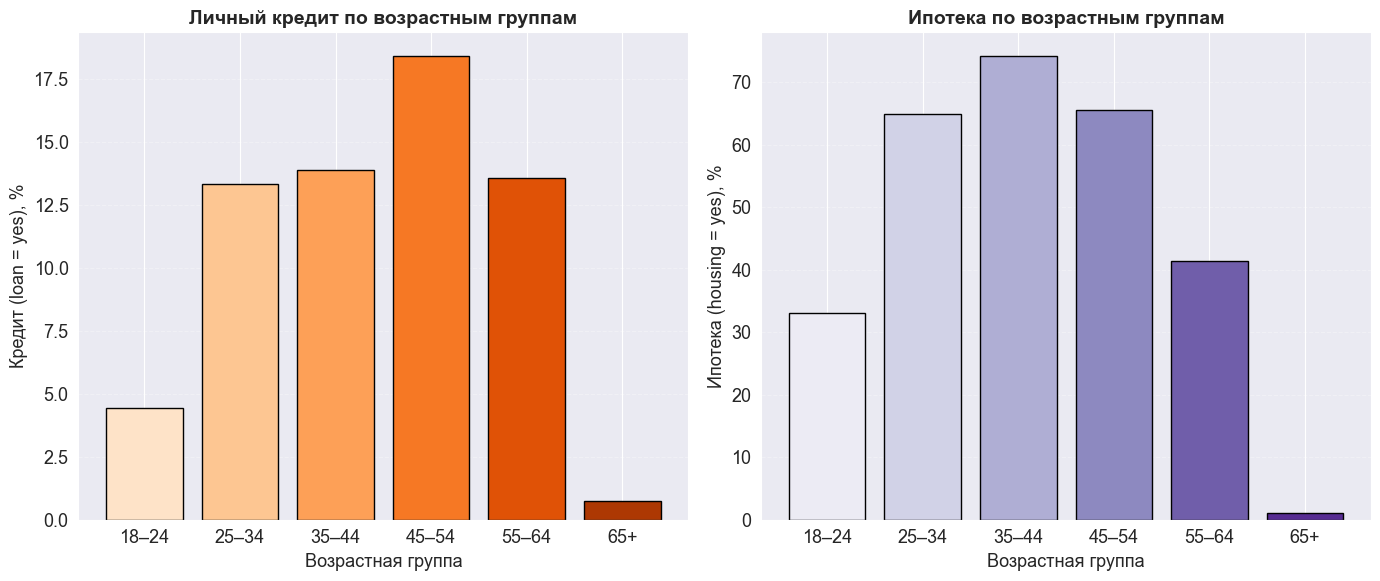

Доля клиентов с личным кредитом по возрастным группам:
age_group  loan_yes_percent
    18–24              4.46
    25–34             13.34
    35–44             13.89
    45–54             18.44
    55–64             13.56
      65+              0.76

Доля клиентов с ипотекой по возрастным группам:
age_group  housing_yes_percent
    18–24                33.12
    25–34                64.87
    35–44                74.31
    45–54                65.59
    55–64                41.46
      65+                 1.14


In [210]:
# Вопрос 15:
# Как возрастные группы (age) связаны с наличием ипотеки (housing) и личного кредита (loan)?
# Какие возрастные категории чаще берут на себя долговую нагрузку?

plt.rcParams.update({'font.size': 13})

# --- 1. Возрастные группы ---
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# --- 2. Кредит ---
loan_stats = (
    df.groupby('age_group', observed=True)['loan']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reset_index()
)
loan_stats['loan_yes_percent'] = loan_stats['yes'] * 100

# --- 3. Ипотека ---
housing_stats = (
    df.groupby('age_group', observed=True)['housing']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reset_index()
)
housing_stats['housing_yes_percent'] = housing_stats['yes'] * 100

# --- 4. Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Кредит
axes[0].bar(
    loan_stats['age_group'].astype(str),
    loan_stats['loan_yes_percent'],
    color=sns.color_palette("Oranges", n_colors=len(loan_stats)),
    edgecolor='black'
)
axes[0].set_title('Личный кредит по возрастным группам', fontsize=14, weight='bold')
axes[0].set_xlabel('Возрастная группа')
axes[0].set_ylabel('Кредит (loan = yes), %')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Ипотека
axes[1].bar(
    housing_stats['age_group'].astype(str),
    housing_stats['housing_yes_percent'],
    color=sns.color_palette("Purples", n_colors=len(housing_stats)),
    edgecolor='black'
)
axes[1].set_title('Ипотека по возрастным группам', fontsize=14, weight='bold')
axes[1].set_xlabel('Возрастная группа')
axes[1].set_ylabel('Ипотека (housing = yes), %')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. Таблицы ---
print("Доля клиентов с личным кредитом по возрастным группам:")
print(loan_stats[['age_group', 'loan_yes_percent']].round(2).to_string(index=False))

print("\nДоля клиентов с ипотекой по возрастным группам:")
print(housing_stats[['age_group', 'housing_yes_percent']].round(2).to_string(index=False))

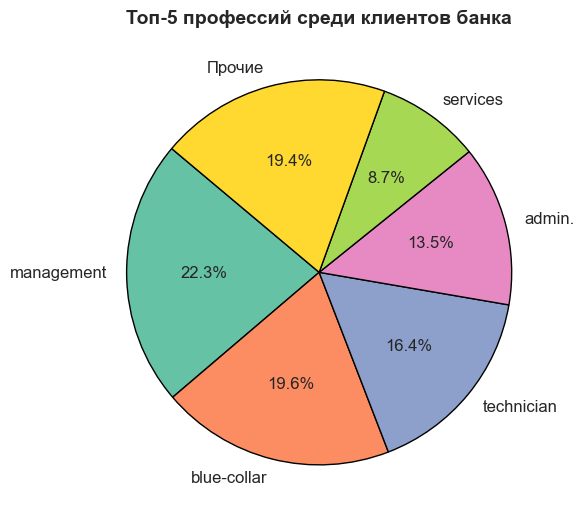

Распределение по профессиям (топ-5 + прочие):
           job  percent
0   management    22.35
1  blue-collar    19.62
2   technician    16.44
3       admin.    13.49
4     services     8.70
5       Прочие    19.40


In [211]:
# Вопрос 16:
# Какие профессии наиболее распространены среди клиентов банка?
# Покажем топ-5 профессий и объединим остальные в категорию "Прочие".

plt.rcParams.update({'font.size': 12})

# 1. Подсчёт долей по профессиям
job_counts = df['job'].value_counts(normalize=True).reset_index()
job_counts.columns = ['job', 'proportion']
job_counts['percent'] = job_counts['proportion'] * 100

# 2. Топ-5 и сумма прочих
top_jobs = job_counts.head(5)
other_sum = job_counts['percent'].iloc[5:].sum()

# 3. Объединение без лишнего столбца
others = pd.DataFrame([{'job': 'Прочие', 'percent': other_sum}])
pie_data = pd.concat([top_jobs[['job', 'percent']], others], ignore_index=True)

# 4. Диаграмма
plt.figure(figsize=(6, 6))
colors = sns.color_palette('Set2', n_colors=len(pie_data))
plt.pie(
    pie_data['percent'],
    labels=pie_data['job'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Топ-5 профессий среди клиентов банка', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# 5. Таблица
print("Распределение по профессиям (топ-5 + прочие):")
print(pie_data.round(2).reset_index(drop=True))